In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bumba5341/advertisingcsv/Advertising.csv


=== TASK 4: SALES FORECASTING METRICS ===
Model R-squared (R²): 0.8986
Mean Absolute Error: 1.47


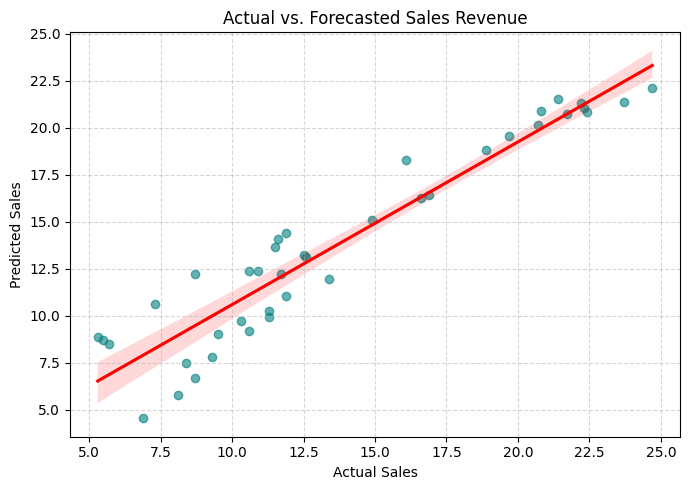

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load your local sales dataset
df = pd.read_csv('/kaggle/input/datasets/bumba5341/advertisingcsv/Advertising.csv') 
df.columns = df.columns.str.strip()

target_col = 'Sales' 

# 2. Auto-isolate features
X = df.drop(columns=[target_col], errors='ignore')
y = df[target_col]

# Select only numeric features (Advertising channels like TV, Radio, Newspaper)
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X[num_features], y, test_size=0.2, random_state=42)

# 3. Production Linear Regression Pipeline
sales_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# 4. Train and Evaluate
sales_pipeline.fit(X_train, y_train)
y_pred = sales_pipeline.predict(X_test)

print("=== TASK 4: SALES FORECASTING METRICS ===")
print(f"Model R-squared (R²): {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

# 5. Visualizing Actual vs Predicted Sales Trend
plt.figure(figsize=(7, 5))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'color':'teal', 'alpha':0.6}, line_kws={'color':'red'})
plt.title("Actual vs. Forecasted Sales Revenue")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("sales_forecast_trend.png")
plt.show()